## 0 · Setup
Imports and plotting style.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, urllib.request
from collections import Counter

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


## 1 · Story 1 — Data Ingestion & "The Clean Up"
> Clean dataset that prevents skewed analysis by bad data entry for **Strategy Director**.

In [2]:
# --- CONFIG -------------------------------------------------------------
DATA_FILENAME = "en.openfoodfacts.org.products.csv.gz"     # relative path
DATA_URL      = "https://static.openfoodfacts.org/data/" + DATA_FILENAME
MAX_SCAN_ROWS = None          # None = scan whole file. Set e.g. 1_000_000 for a fast first pass.

USECOLS = ["code","product_name","categories_tags","sugars_100g","proteins_100g",
           "fat_100g","carbohydrates_100g","fiber_100g","salt_100g",
           "energy-kcal_100g","ingredients_text","nutriscore_grade"]

if not os.path.exists(DATA_FILENAME):
    print("Downloading Open Food Facts export (one-time, ~1GB)...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILENAME)
    print("Download complete.")
else:
    print("Using existing local file:", DATA_FILENAME)

Download complete.


In [3]:
# --- CHUNKED, SNACK-FILTERED INGEST -------------------------------------
# I keep memory bounded by filtering to snack-aisle rows inside each chunk,
# rather than loading 4M rows into RAM. This is the brief's "specific categories"
# approach (smarter than "first 500k rows", which would just be alphabetical).
SNACK_HINTS = ["snack","biscuit","cookie","cake","chocolate","candy","candies","crisp",
               "chips","cracker","nut","seed","bar","dried-fruit","yogurt","yoghurt",
               "popcorn","pretzel","wafer","confection","cereal"]

def snack_mask(tag_series):
    s = tag_series.fillna("").str.lower()
    m = np.zeros(len(s), dtype=bool)
    for h in SNACK_HINTS:
        m |= s.str.contains(h, regex=False).to_numpy()
    return m

reader = pd.read_csv(DATA_FILENAME, sep="\t", usecols=lambda c: c in USECOLS,
                     dtype={"code": str}, chunksize=250_000,
                     on_bad_lines="skip", low_memory=False)

parts, scanned = [], 0
for chunk in reader:
    scanned += len(chunk)
    parts.append(chunk[snack_mask(chunk["categories_tags"])])
    if MAX_SCAN_ROWS and scanned >= MAX_SCAN_ROWS:
        break

raw = pd.concat(parts, ignore_index=True)
start_rows = len(raw)
print(f"Scanned {scanned:,} rows · kept {start_rows:,} snack-aisle products")
raw.head(3)

Scanned 4,532,767 rows · kept 628,232 snack-aisle products


,code,product_name,categories_tags,ingredients_text,nutriscore_grade,energy-kcal_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,00000007,granola Bio le Chocolaté,"en:plant-based-foods-and-beverages,en:plant-ba...",HONIG stillende Frauen nicht geeignet. D bestr...,c,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00000010,xxx,"en:beverages-and-beverages-preparations,en:bev...","Farine de blé 33%, sucre, huile de colza, œufs...",unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00000013,Powdered peanut butter,"en:snacks,en:meals,en:rice-dishes,en:risottos,...","Water, Leptospermum Scoparium Mel (Manuka Hone...",c,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1b · The Clean-Up
**Decisions (and why):**

- **Missing `product_name`, `sugars_100g`, `proteins_100g` → drop the row.** These three are the spine of the analysis. *Imputing* nutrition values would fabricate data and bias the very gap we're hunting for, so we remove rather than fill.

- **Biologically impossible values → drop.** Every `*_100g` field is grams *per 100 g*, so it must sit in **[0, 100]**. Energy is capped at **900 kcal/100g** (pure fat, the physical ceiling). **Sugar can't exceed carbohydrates** (sugar is a subset of carbs). The **sum of macros can't exceed ~105 g** per 100 g.

In [4]:
df = raw.copy()
NUM = ["sugars_100g","proteins_100g","fat_100g","carbohydrates_100g",
       "fiber_100g","salt_100g","energy-kcal_100g"]
for c in NUM:
    df[c] = pd.to_numeric(df[c], errors="coerce")

log = {}
df["product_name"] = df["product_name"].astype("string").str.strip()
b = len(df)
df = df[df["product_name"].notna() & (df["product_name"] != "")]
df = df.dropna(subset=["sugars_100g","proteins_100g"])
log["missing product_name / sugars / proteins"] = b - len(df)

b = len(df)
for c in ["sugars_100g","proteins_100g","fat_100g","carbohydrates_100g","fiber_100g","salt_100g"]:
    df = df[df[c].isna() | ((df[c] >= 0) & (df[c] <= 100))]
log["out of 0-100 g/100g range"] = b - len(df)

b = len(df); e = "energy-kcal_100g"
df = df[df[e].isna() | ((df[e] >= 0) & (df[e] <= 900))]
log["impossible energy (>900 kcal/100g)"] = b - len(df)

b = len(df)
df = df[~(df["carbohydrates_100g"].notna() & (df["sugars_100g"] > df["carbohydrates_100g"] + 0.5))]
log["sugar > carbohydrates"] = b - len(df)

b = len(df)
macro = df[["proteins_100g","fat_100g","carbohydrates_100g"]].sum(axis=1, min_count=1)
df = df[macro.isna() | (macro <= 105)]
log["macro sum > 105 g/100g"] = b - len(df)

df = df.drop_duplicates(subset=["code"]).reset_index(drop=True)

print("CLEANING LOG (rows removed):")
for k, v in log.items():
    print(f"  - {k:<38} {v:>8,}")
print(f"\nRetained {len(df):,} of {start_rows:,} snack rows ({len(df)/start_rows:.1%}).")

CLEANING LOG (rows removed):
  - missing product_name / sugars / proteins  226,918
  - out of 0-100 g/100g range                   542
  - impossible energy (>900 kcal/100g)          608
  - sugar > carbohydrates                       269
  - macro sum > 105 g/100g                      274

Retained 399,621 of 628,232 snack rows (63.6%).


## 2 · Story 2 — The Category Wrangler
> Readable high-level categories to group products for **Product Manager**.

In [5]:
CATEGORY_RULES = [
    ("Cereal & Protein Bars",      ["protein-bar","cereal-bar","energy-bar","granola-bar","bars","bar"]),
    ("Nuts, Seeds & Trail Mix",    ["nut","seed","almond","cashew","peanut","pistachio","trail-mix","walnut"]),
    ("Chips & Savory Snacks",      ["crisp","chip","salty-snack","savoury","savory","popcorn","pretzel","appetizer"]),
    ("Crackers & Bread Snacks",    ["cracker","crispbread","rusk","breadstick","toast"]),
    ("Chocolate & Confectionery",  ["chocolate","candy","candies","confectioner","praline","truffle"]),
    ("Biscuits, Cookies & Cakes",  ["biscuit","cookie","cake","wafer","pastry","brownie"]),
    ("Dried Fruit & Fruit Snacks", ["dried-fruit","dried-products","raisin","fruit-snack","fruits-based"]),
    ("Dairy & Yogurt Snacks",      ["yogurt","yoghurt","dairy","dairies","fromage","cheese-snack"]),
]

def normalize_tags(s):
    if pd.isna(s): return ""
    parts = [re.sub(r"^[a-z]{2}:", "", p.strip().lower()) for p in str(s).split(",")]
    return " ".join(parts)

df["tags_norm"]   = df["categories_tags"].apply(normalize_tags)
df["search_blob"] = df["tags_norm"] + " " + df["product_name"].str.lower().fillna("")

def assign_category(blob):
    for name, kws in CATEGORY_RULES:
        if any(k in blob for k in kws):
            return name
    return "Other Snacks"

df["primary_category"] = df["search_blob"].apply(assign_category)

dist = df["primary_category"].value_counts()
print(f"Distinct high-level buckets: {df['primary_category'].nunique()}  (brief requires >= 5)\n")
print(dist.to_string())

Distinct high-level buckets: 9  (brief requires >= 5)

primary_category
Other Snacks                  88937
Chocolate & Confectionery     75419
Nuts, Seeds & Trail Mix       71713
Biscuits, Cookies & Cakes     39524
Chips & Savory Snacks         35837
Dairy & Yogurt Snacks         33707
Cereal & Protein Bars         24626
Crackers & Bread Snacks       19343
Dried Fruit & Fruit Snacks    10515


/tmp/ipykernel_3187/2686402083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=order, palette="crest", ax=ax)


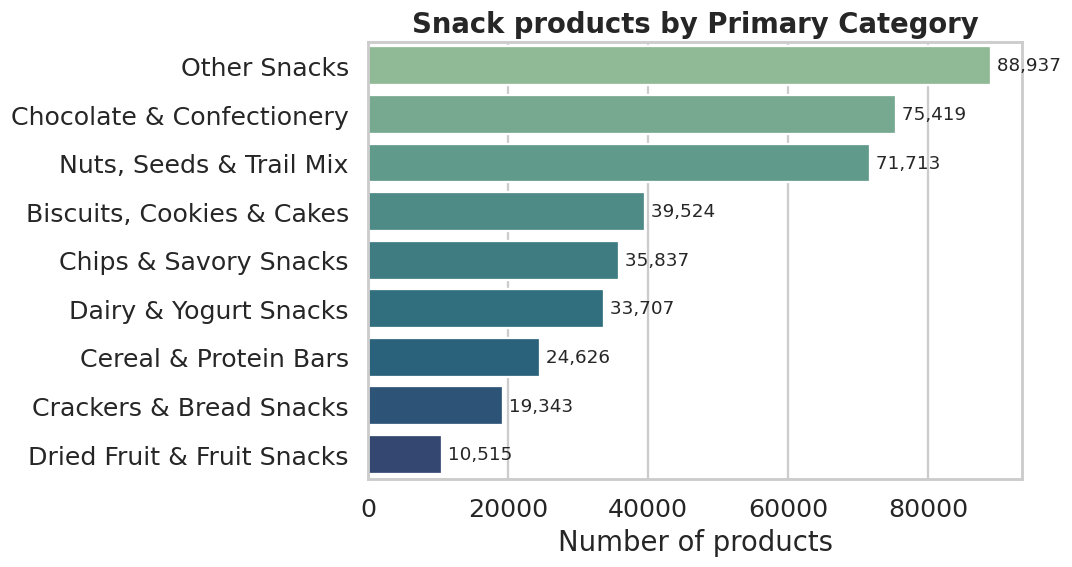

In [6]:
fig, ax = plt.subplots(figsize=(10,5.5))
order = dist.index
sns.barplot(x=dist.values, y=order, palette="crest", ax=ax)
ax.set_title("Snack products by Primary Category", weight="bold")
ax.set_xlabel("Number of products"); ax.set_ylabel("")
for i, v in enumerate(dist.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=12)
plt.tight_layout(); plt.show()

## 3 · Story 3 — The "Nutrient Matrix"
> Scatter plot of Sugar (X) vs Protein (Y) by category for **Marketing Lead** to visually spot where products cluster.

In [7]:
HIGH_PROTEIN, LOW_SUGAR = 10.0, 5.0
df["is_high_protein"] = df["proteins_100g"] >= HIGH_PROTEIN
df["is_low_sugar"]    = df["sugars_100g"]   <= LOW_SUGAR
df["quadrant"] = np.select(
    [df.is_high_protein & df.is_low_sugar,
     df.is_high_protein & ~df.is_low_sugar,
     ~df.is_high_protein & df.is_low_sugar],
    ["High Protein / Low Sugar (TARGET)","High Protein / High Sugar","Low Protein / Low Sugar"],
    default="Low Protein / High Sugar")

share = (df["quadrant"].value_counts(normalize=True)*100).round(1)
print("Share of all snack products by quadrant:\n", share.to_string())

Share of all snack products by quadrant:
 quadrant
Low Protein / High Sugar             51.5
Low Protein / Low Sugar              23.4
High Protein / Low Sugar (TARGET)    15.9
High Protein / High Sugar             9.2


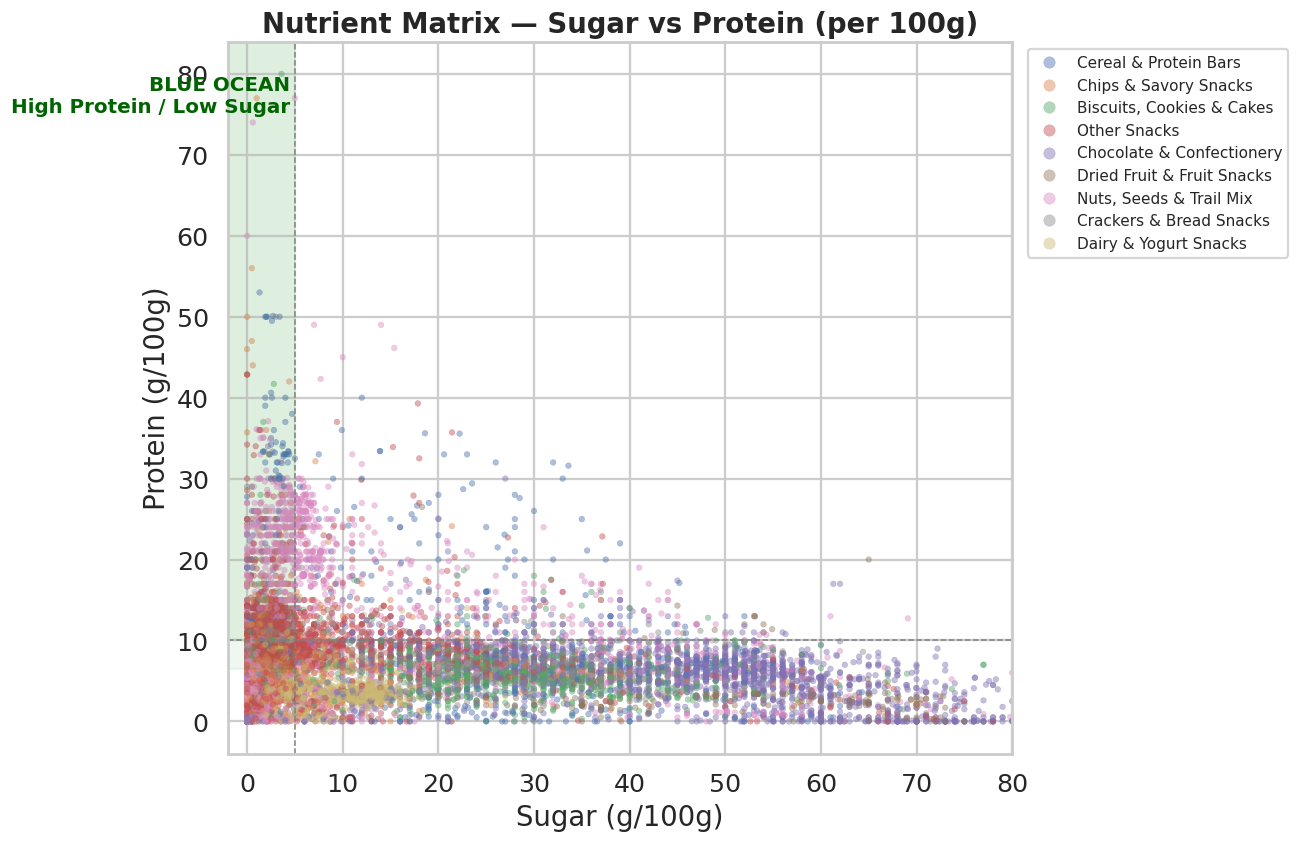

In [8]:
# Product-level scatter (sampled for legibility) with the TARGET quadrant shaded
plot_df = df.sample(min(12000, len(df)), random_state=1)
fig, ax = plt.subplots(figsize=(12,8))
sns.scatterplot(data=plot_df, x="sugars_100g", y="proteins_100g",
                hue="primary_category", s=14, alpha=0.45, edgecolor=None, ax=ax)
ax.axvline(LOW_SUGAR, color="grey", ls="--", lw=1)
ax.axhline(HIGH_PROTEIN, color="grey", ls="--", lw=1)
ax.axvspan(-2, LOW_SUGAR, ymin=HIGH_PROTEIN/ax.get_ylim()[1], color="green", alpha=0.06)
ax.add_patch(plt.Rectangle((-2, HIGH_PROTEIN), LOW_SUGAR+2, 100, color="green", alpha=0.07, zorder=0))
ax.text(LOW_SUGAR-0.5, ax.get_ylim()[1]*0.95, "BLUE OCEAN\nHigh Protein / Low Sugar",
        ha="right", va="top", weight="bold", color="darkgreen", fontsize=13)
ax.set_xlim(-2, 80)
ax.set_title("Nutrient Matrix — Sugar vs Protein (per 100g)", weight="bold")
ax.set_xlabel("Sugar (g/100g)"); ax.set_ylabel("Protein (g/100g)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=10, markerscale=2)
plt.tight_layout(); plt.show()

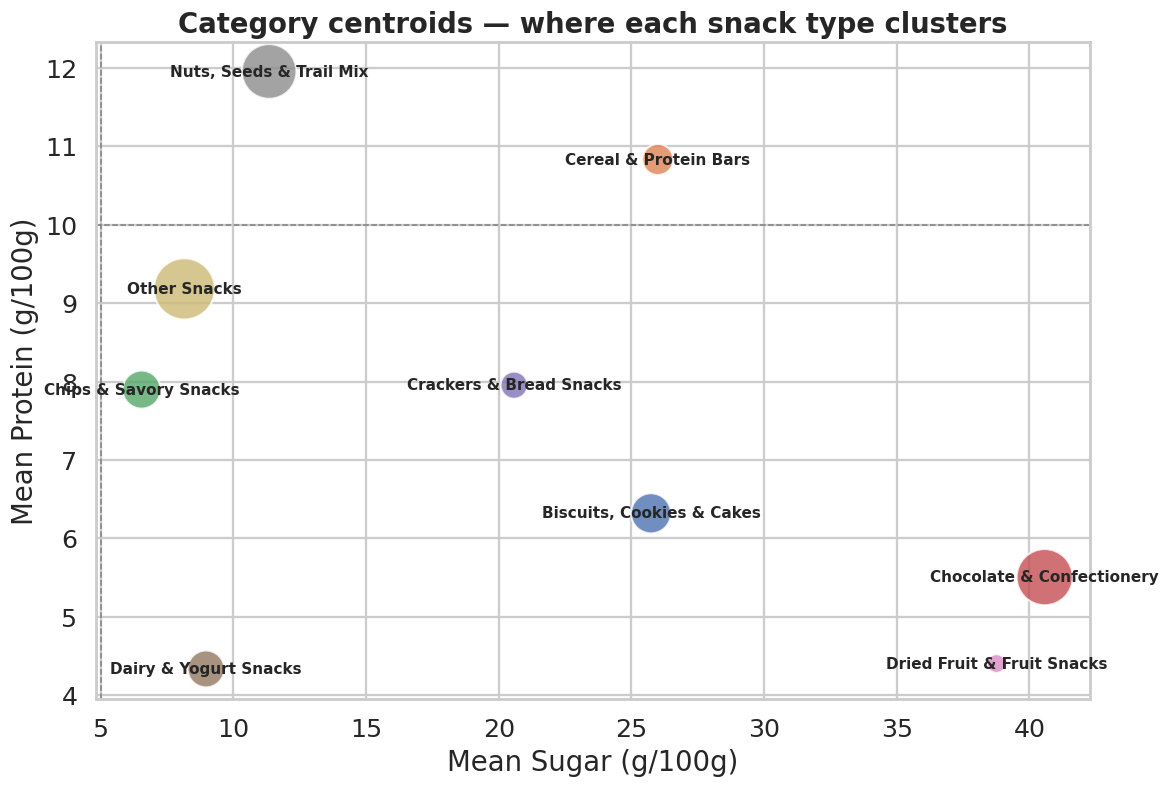

In [9]:
# Category CENTROIDS — the clearest view of "where each category lives"
cent = df.groupby("primary_category").agg(
    mean_sugar=("sugars_100g","mean"), mean_protein=("proteins_100g","mean"),
    n=("code","size")).reset_index()
fig, ax = plt.subplots(figsize=(11,7.5))
sns.scatterplot(data=cent, x="mean_sugar", y="mean_protein", size="n",
                hue="primary_category", sizes=(150,1600), alpha=0.8, ax=ax, legend="brief")
for _, r in cent.iterrows():
    ax.annotate(r["primary_category"], (r["mean_sugar"], r["mean_protein"]),
                fontsize=10, weight="bold", ha="center", va="center")
ax.axvline(LOW_SUGAR, color="grey", ls="--", lw=1); ax.axhline(HIGH_PROTEIN, color="grey", ls="--", lw=1)
ax.set_title("Category centroids — where each snack type clusters", weight="bold")
ax.set_xlabel("Mean Sugar (g/100g)"); ax.set_ylabel("Mean Protein (g/100g)")
ax.get_legend().remove(); plt.tight_layout(); plt.show()

## 4 · Story 4 — The Recommendation
> Recommendation for **Client** on what product we should build, to be taken to R&D team.

The true *Sugar-Trap* opportunity scores on **three** axes at once:

`Opportunity = Demand × Trap-Depth × Unmet-Need`

- **Demand** = category size (normalised) — proven appetite.
- **Trap-Depth** = mean sugar (normalised) — how stuck in the sugar trap it is.
- **Unmet-Need** = `1 − share already High-Protein/Low-Sugar` — how empty the healthy quadrant is.

A category must score on **all three** to win.

In [10]:
opp = df.groupby("primary_category").agg(
    total=("code","size"),
    mean_sugar=("sugars_100g","mean"),
    mean_protein=("proteins_100g","mean"),
    target_n=("quadrant", lambda q: (q=="High Protein / Low Sugar (TARGET)").sum()),
).reset_index()
opp["pct_target"] = (opp["target_n"]/opp["total"]*100).round(2)

demand     = opp["total"]      / opp["total"].max()
trap_depth = opp["mean_sugar"] / opp["mean_sugar"].max()
unmet      = 1 - opp["target_n"]/opp["total"]
opp["opportunity_score"] = (demand*trap_depth*unmet*100).round(1)
opp = opp.sort_values("opportunity_score", ascending=False).reset_index(drop=True)
print(opp.round(2).to_string(index=False))

          primary_category  total  mean_sugar  mean_protein  target_n  pct_target  opportunity_score
 Chocolate & Confectionery  75419       40.57          5.50      1524        2.02               83.1
 Biscuits, Cookies & Cakes  39524       25.74          6.32      1021        2.58               27.5
   Nuts, Seeds & Trail Mix  71713       11.35         11.96     20087       28.01               16.2
     Cereal & Protein Bars  24626       26.00         10.83      3412       13.86               15.3
              Other Snacks  88937        8.15          9.18     26428       29.72               14.1
Dried Fruit & Fruit Snacks  10515       38.76          4.40       357        3.40               10.9
   Crackers & Bread Snacks  19343       20.58          7.95      3260       16.85                9.2
     Dairy & Yogurt Snacks  33707        8.97          4.33      1018        3.02                8.1
     Chips & Savory Snacks  35837        6.54          7.90      6569       18.33          

/tmp/ipykernel_3187/2225299621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=opp, x="opportunity_score", y="primary_category", palette="flare", ax=ax)


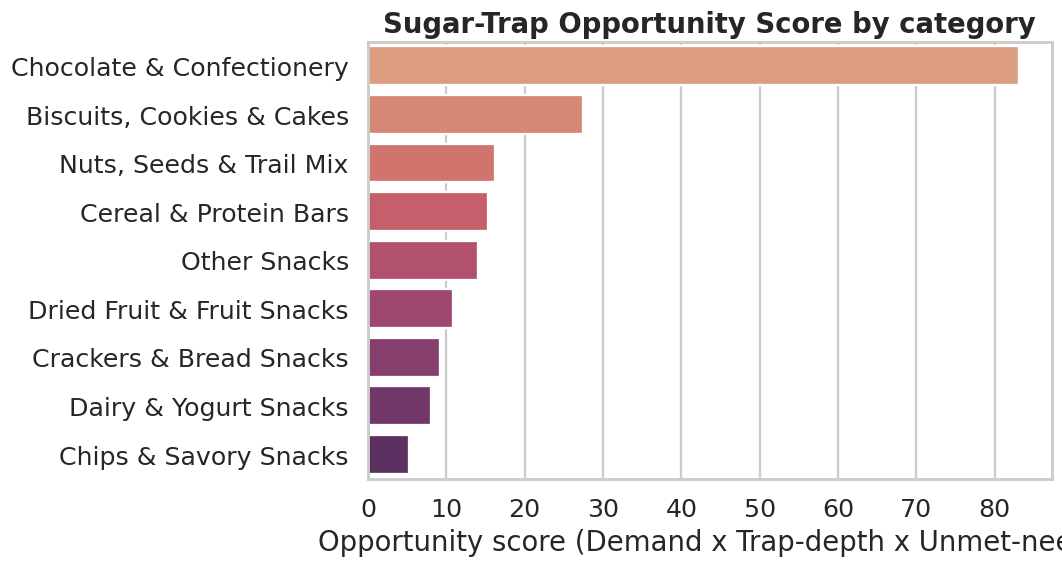

In [11]:
fig, ax = plt.subplots(figsize=(10,5.5))
sns.barplot(data=opp, x="opportunity_score", y="primary_category", palette="flare", ax=ax)
ax.set_title("Sugar-Trap Opportunity Score by category", weight="bold")
ax.set_xlabel("Opportunity score (Demand x Trap-depth x Unmet-need)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [12]:
best = opp[opp["primary_category"] != "Other Snacks"].iloc[0]   # headline must be an actionable, named category
best_cat = best["primary_category"]
sub = df[df["primary_category"] == best_cat]
rec_protein = int(round(sub["proteins_100g"].quantile(0.75)))   # top-quartile, proven achievable
rec_sugar   = int(LOW_SUGAR)

RECOMMENDATION = (f"Based on the data, the biggest market opportunity is in {best_cat}, "
                  f"specifically targeting products with {rec_protein}g of protein "
                  f"and less than {rec_sugar}g of sugar.")
print("="*78); print("KEY INSIGHT / RECOMMENDATION"); print("="*78)
print(RECOMMENDATION)
print(f"\nWhy: {best_cat} has {int(best['total']):,} products, averages "
      f"{best['mean_sugar']:.1f}g sugar, yet only {best['pct_target']:.1f}% are already "
      f"high-protein/low-sugar — a near-empty quadrant in a high-demand aisle.")

KEY INSIGHT / RECOMMENDATION
Based on the data, the biggest market opportunity is in Chocolate & Confectionery, specifically targeting products with 7g of protein and less than 5g of sugar.

Why: Chocolate & Confectionery has 75,419 products, averages 40.6g sugar, yet only 2.0% are already high-protein/low-sugar — a near-empty quadrant in a high-demand aisle.


## 5 · Bonus — The "Hidden Gem"
> Ingredients driving the high protein in the "good" products for **Health Conscious Consumer** to be replicateed.

Analysed 63,676 products in the High-Protein/Low-Sugar cluster.

Top protein sources:
 Wheat/Gluten       5882
Soy                2636
Sunflower seed     2106
Oats               1606
Lentil/Chickpea    1097
Peanut              947
Whey                815
Almond              761

>>> TOP 3 PROTEIN SOURCES: Wheat/Gluten, Soy, Sunflower seed


/tmp/ipykernel_3187/695680131.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.head(8).values, y=top.head(8).index, palette="viridis", ax=ax)


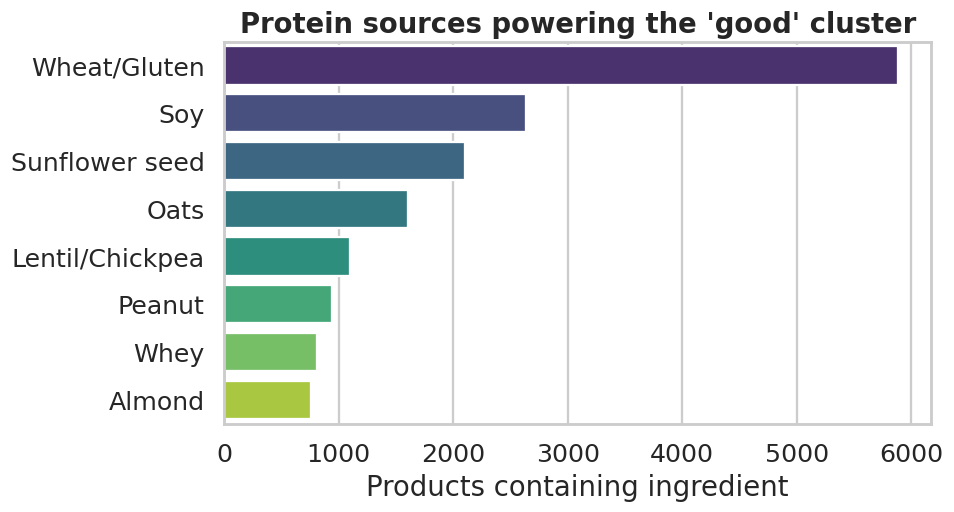

In [13]:
good = df[df["quadrant"] == "High Protein / Low Sugar (TARGET)"]
PROTEIN_SOURCES = {
    "Whey":["whey"], "Milk protein/Casein":["milk protein","casein","caseinate"],
    "Soy":["soy","soya"], "Peanut":["peanut"], "Almond":["almond"], "Egg":["egg"],
    "Pea protein":["pea protein"], "Cashew":["cashew"], "Wheat/Gluten":["gluten","wheat protein","seitan"],
    "Oats":["oat"], "Lentil/Chickpea":["lentil","chickpea"], "Sunflower seed":["sunflower"],
    "Hazelnut":["hazelnut"], "Pumpkin seed":["pumpkin seed"],
}
counts = Counter()
for txt in good["ingredients_text"].dropna().str.lower():
    for label, kws in PROTEIN_SOURCES.items():
        if any(k in txt for k in kws):
            counts[label] += 1

top = pd.Series(dict(counts)).sort_values(ascending=False)
top3 = top.head(3)
print(f"Analysed {len(good):,} products in the High-Protein/Low-Sugar cluster.")
print("\nTop protein sources:\n", top.head(8).to_string())
print("\n>>> TOP 3 PROTEIN SOURCES:", ", ".join(top3.index[:3]))

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=top.head(8).values, y=top.head(8).index, palette="viridis", ax=ax)
ax.set_title("Protein sources powering the 'good' cluster", weight="bold")
ax.set_xlabel("Products containing ingredient"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 6 · Candidate's Choice — The "Health Integrity Check"
**What I added:** A check that the target cluster isn't a *fake-healthy* product — i.e. that "low sugar" hasn't been bought with **high fat or high salt**, this is because the classic reformulation trap is to strip sugar and quietly replace it with fat or salt, producing a "health halo" product that fails the moment a journalist reads the label. Before Helix's client invests in the blue-ocean category, leadership should see whether the *existing* healthy snacks are genuinely clean — and where the recipe risk lies.

Health Integrity Check — median per 100g:
            All snacks  Target cluster
Fat (g)         11.00            7.14
Salt (g)         0.26            0.11
Fiber (g)        3.20            6.25


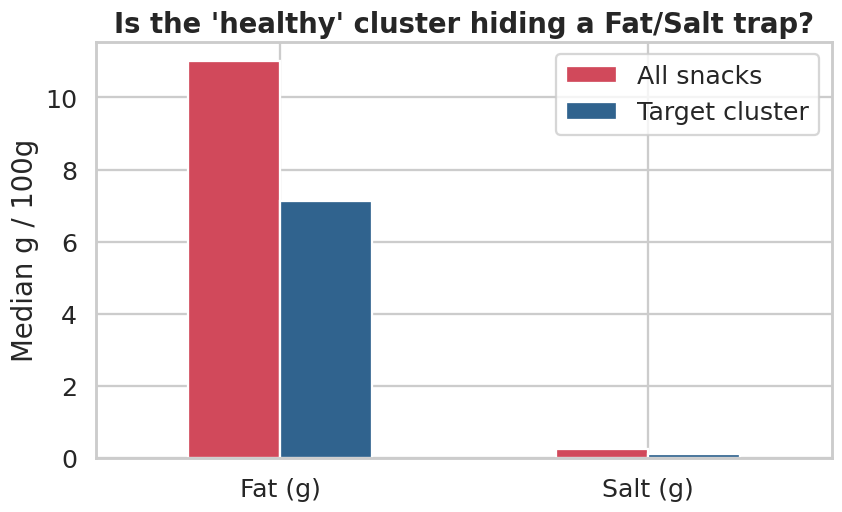


Verdict: target-cluster fat is clean.


In [14]:
overall = df[["fat_100g","salt_100g","fiber_100g"]].median()
target  = good[["fat_100g","salt_100g","fiber_100g"]].median()
comp = pd.DataFrame({"All snacks": overall, "Target cluster": target}).round(2)
comp.index = ["Fat (g)","Salt (g)","Fiber (g)"]
print("Health Integrity Check — median per 100g:\n", comp.to_string())

fig, ax = plt.subplots(figsize=(8,5))
comp.loc[["Fat (g)","Salt (g)"]].plot(kind="bar", ax=ax, color=["#d1495b","#30638e"])
ax.set_title("Is the 'healthy' cluster hiding a Fat/Salt trap?", weight="bold")
ax.set_ylabel("Median g / 100g"); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

fat_flag = "ELEVATED — recipe must control fat" if target["fat_100g"] > overall["fat_100g"] else "clean"
print(f"\nVerdict: target-cluster fat is {fat_flag}.")

In [15]:
export_cols = ["code","product_name","primary_category","sugars_100g","proteins_100g",
               "fat_100g","fiber_100g","salt_100g","energy-kcal_100g",
               "is_high_protein","is_low_sugar","quadrant"]
df[export_cols].to_csv("powerbi_products_clean.csv", index=False)
opp.round(3).to_csv("powerbi_category_summary.csv", index=False)
print("Wrote: powerbi_products_clean.csv  (", len(df), "rows )")
print("Wrote: powerbi_category_summary.csv (", len(opp), "rows )")

#from google.colab import files
#files.download("powerbi_products_clean.csv")
#files.download("powerbi_category_summary.csv")

Wrote: powerbi_products_clean.csv  ( 399621 rows )
Wrote: powerbi_category_summary.csv ( 9 rows )


In [17]:
#SUMMARY
t3 = ", ".join(top3.index[:3])
print("="*80)
print("SUGAR TRAP — RESULTS SUMMARY")
print("="*80)
print(f"Raw snack rows scanned-kept : {start_rows:,}")
print(f"Clean rows after Story 1    : {len(df):,}  ({len(df)/start_rows:.1%} retained)")
print(f"High-level categories       : {df['primary_category'].nunique()}")
print("\nQuadrant shares (% of all snacks):")
print(share.to_string())
print("\nTop-3 opportunity categories:")
print(opp[['primary_category','total','mean_sugar','mean_protein','pct_target','opportunity_score']].head(3).round(2).to_string(index=False))
print(f"\nRECOMMENDATION:\n{RECOMMENDATION}")
print(f"\nBONUS — Top 3 protein sources: {t3}")
print("\nCANDIDATE'S CHOICE — Health Integrity (median g/100g):")
print(comp.to_string())
print("="*80)

SUGAR TRAP — RESULTS SUMMARY
Raw snack rows scanned-kept : 628,232
Clean rows after Story 1    : 399,621  (63.6% retained)
High-level categories       : 9

Quadrant shares (% of all snacks):
quadrant
Low Protein / High Sugar             51.5
Low Protein / Low Sugar              23.4
High Protein / Low Sugar (TARGET)    15.9
High Protein / High Sugar             9.2

Top-3 opportunity categories:
         primary_category  total  mean_sugar  mean_protein  pct_target  opportunity_score
Chocolate & Confectionery  75419       40.57          5.50        2.02               83.1
Biscuits, Cookies & Cakes  39524       25.74          6.32        2.58               27.5
  Nuts, Seeds & Trail Mix  71713       11.35         11.96       28.01               16.2

RECOMMENDATION:
Based on the data, the biggest market opportunity is in Chocolate & Confectionery, specifically targeting products with 7g of protein and less than 5g of sugar.

BONUS — Top 3 protein sources: Wheat/Gluten, Soy, Sunflower se